In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots a bit nicer
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Ensure we can import config.py from project root
ROOT = Path.cwd().parents[0]  # if notebook is in notebooks/
sys.path.append(str(ROOT))

from config import EPC_CLEAN_SW_DIR  # directory with part_*.parquet

EPC_CLEAN_SW_DIR

PosixPath('/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw')

In [2]:
# List all parquet part files
part_files = sorted(EPC_CLEAN_SW_DIR.glob("part_*.parquet"))
part_files

[PosixPath('/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw/part_000.parquet'),
 PosixPath('/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw/part_001.parquet'),
 PosixPath('/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw/part_002.parquet'),
 PosixPath('/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw/part_003.parquet'),
 PosixPath('/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw/part_004.parquet'),
 PosixPath('/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw/part_005.parquet'),
 PosixPath('/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_ep

In [4]:
# Load all South West cleaned data into one DataFrame
df_list = [pd.read_parquet(p) for p in part_files]
df = pd.concat(df_list, ignore_index=True)

df.shape, df.head()

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

In [5]:
import pyarrow
import pandas as pd

pd.DataFrame({"a":[1]}).to_parquet("test.parquet")
pd.read_parquet("test.parquet")

ModuleNotFoundError: No module named 'pyarrow'

In [6]:
import sys, subprocess

print(sys.executable)  # just to double-check it's the .venv one
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
subprocess.run([sys.executable, "-m", "pip", "install", "pyarrow>=14.0", "pandas>=2.1"])

/Users/divyanshu/.pyenv/versions/3.11.9/bin/python
  Using cached pip-25.3-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.3-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.0
    Uninstalling pip-24.0:
      Successfully uninstalled pip-24.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 8.1 MB/s  0:00:04 eta 0:00:01


CompletedProcess(args=['/Users/divyanshu/.pyenv/versions/3.11.9/bin/python', '-m', 'pip', 'install', 'pyarrow>=14.0', 'pandas>=2.1'], returncode=0)

In [8]:
import pandas as pd
import pyarrow

print("pandas:", pd.__version__)
print("pyarrow:", pyarrow.__version__)

df = pd.DataFrame({"a": [1, 2, 3]})
df.to_parquet("test.parquet")
df2 = pd.read_parquet("test.parquet")
print(df2)


pandas: 2.3.3
pyarrow: 22.0.0


ArrowKeyError: A type extension with name pandas.period already defined

In [10]:
!pip install polars

  Using cached polars-1.35.2-py3-none-any.whl.metadata (10 kB)
  Using cached polars_runtime_32-1.35.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (1.5 kB)
Using cached polars-1.35.2-py3-none-any.whl (783 kB)
Using cached polars_runtime_32-1.35.2-cp39-abi3-macosx_11_0_arm64.whl (36.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [polars]2m1/2 [polars]


In [11]:
import polars as pl
from pathlib import Path

DATA_DIR = Path("../data/processed/ew_epc_core_clean_sw")

# read all CSV.gz files
df = pl.read_csv(
    list(DATA_DIR.glob("part_*.csv.gz")),
    ignore_errors=True
)

df
print(df.shape)

TypeError: Object does not have a .read() method.

In [12]:
from pathlib import Path
import polars as pl

DATA_DIR = Path("../data/processed/ew_epc_core_clean_sw")

# 1. Get all part_XXX.csv.gz files as a list of strings
files = sorted(DATA_DIR.glob("part_*.csv.gz"))
print(f"Found {len(files)} files")

# IMPORTANT: convert Path objects → str for Polars
file_paths = [str(f) for f in files]

# 2. Read them all at once
df = pl.read_csv(
    file_paths,
    ignore_errors=True,  # if there is some weird row, it will skip it
)

print(df.shape)
df.head()

Found 29 files


TypeError: Object does not have a .read() method.

In [13]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/processed/ew_epc_core_clean_sw")

files = sorted(DATA_DIR.glob("part_*.csv.gz"))
print(f"Found {len(files)} files")

df = pd.concat(
    (pd.read_csv(f) for f in files),
    ignore_index=True
)

print(df.shape)
df.head()

Found 29 files


/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_39656/3801098380.py:10: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  (pd.read_csv(f) for f in files),


(1807888, 33)


,LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,...,MAIN_HEATING_CONTROLS,YEAR,MAIN_FUEL_STD,TENURE_STD,AGE_BAND_STD,EFFICIENCY_GAP,EPC_BAND_SCORE,HAS_MAINS_GAS,IS_ELECTRIC_HEAT,BELOW_C
0,29087020002008100209344654182258,BH1 3QF,E06000058,"Bournemouth, Christchurch and Poole",2008-10-02 00:00:00+00:00,B,84,B,85,132,...,NaN,2008,other,Unknown,NO DATA!,1,6,False,False,False
1,162691330702008101308085753289378,SN5 5RZ,E06000030,Swindon,2008-10-13 00:00:00+00:00,C,69,C,76,275,...,2107,2008,other,Rented (private),England and Wales: 1983-1990,7,5,True,False,False
2,177427449952008110523461208089155,BA1 6JH,E06000022,Bath and North East Somerset,2008-11-05 00:00:00+00:00,D,58,D,62,424,...,2402,2008,other,Unknown,England and Wales: 1967-1975,4,4,False,False,True
3,37743650742008111311541854389578,PL14 4NP,E06000052,Cornwall,2008-11-13 00:00:00+00:00,E,44,E,52,549,...,2401,2008,other,Owner-occupied,England and Wales: 1996-2002,8,3,False,False,True
4,158859350832008101718063789968495,PL26 8EY,E06000052,Cornwall,2008-10-17 00:00:00+00:00,D,57,D,59,471,...,2401,2008,other,Unknown,England and Wales: 1983-1990,2,4,False,False,True


In [14]:
df.shape
df.columns
df.head()


,LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,...,MAIN_HEATING_CONTROLS,YEAR,MAIN_FUEL_STD,TENURE_STD,AGE_BAND_STD,EFFICIENCY_GAP,EPC_BAND_SCORE,HAS_MAINS_GAS,IS_ELECTRIC_HEAT,BELOW_C
0,29087020002008100209344654182258,BH1 3QF,E06000058,"Bournemouth, Christchurch and Poole",2008-10-02 00:00:00+00:00,B,84,B,85,132,...,NaN,2008,other,Unknown,NO DATA!,1,6,False,False,False
1,162691330702008101308085753289378,SN5 5RZ,E06000030,Swindon,2008-10-13 00:00:00+00:00,C,69,C,76,275,...,2107,2008,other,Rented (private),England and Wales: 1983-1990,7,5,True,False,False
2,177427449952008110523461208089155,BA1 6JH,E06000022,Bath and North East Somerset,2008-11-05 00:00:00+00:00,D,58,D,62,424,...,2402,2008,other,Unknown,England and Wales: 1967-1975,4,4,False,False,True
3,37743650742008111311541854389578,PL14 4NP,E06000052,Cornwall,2008-11-13 00:00:00+00:00,E,44,E,52,549,...,2401,2008,other,Owner-occupied,England and Wales: 1996-2002,8,3,False,False,True
4,158859350832008101718063789968495,PL26 8EY,E06000052,Cornwall,2008-10-17 00:00:00+00:00,D,57,D,59,471,...,2401,2008,other,Unknown,England and Wales: 1983-1990,2,4,False,False,True


In [15]:
df

,LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,...,MAIN_HEATING_CONTROLS,YEAR,MAIN_FUEL_STD,TENURE_STD,AGE_BAND_STD,EFFICIENCY_GAP,EPC_BAND_SCORE,HAS_MAINS_GAS,IS_ELECTRIC_HEAT,BELOW_C
0,29087020002008100209344654182258,BH1 3QF,E06000058,"Bournemouth, Christchurch and Poole",2008-10-02 00:00:00+00:00,B,84,B,85,132,...,NaN,2008,other,Unknown,NO DATA!,1,6,False,False,False
1,162691330702008101308085753289378,SN5 5RZ,E06000030,Swindon,2008-10-13 00:00:00+00:00,C,69,C,76,275,...,2107,2008,other,Rented (private),England and Wales: 1983-1990,7,5,True,False,False
2,177427449952008110523461208089155,BA1 6JH,E06000022,Bath and North East Somerset,2008-11-05 00:00:00+00:00,D,58,D,62,424,...,2402,2008,other,Unknown,England and Wales: 1967-1975,4,4,False,False,True
3,37743650742008111311541854389578,PL14 4NP,E06000052,Cornwall,2008-11-13 00:00:00+00:00,E,44,E,52,549,...,2401,2008,other,Owner-occupied,England and Wales: 1996-2002,8,3,False,False,True
4,158859350832008101718063789968495,PL26 8EY,E06000052,Cornwall,2008-10-17 00:00:00+00:00,D,57,D,59,471,...,2401,2008,other,Unknown,England and Wales: 1983-1990,2,4,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1807883,03c5078838a4bccc40c0f49c4c625b90643adc2c6782f3...,PL18 9FX,E06000052,Cornwall,2025-09-27 00:00:00+00:00,B,81,B,83,42,...,NaN,2025,other,Unknown,2025,2,6,False,False,False
1807884,03f441b2da88c81db1bda5f034684b7a1b29a2934e0646...,BA3 4HQ,E06000066,Somerset,2025-09-25 00:00:00+00:00,D,55,D,67,297,...,NaN,2025,gas,Owner-occupied,England and Wales: 1900-1929,12,4,True,False,True
1807885,03f5764afc2d5ac08ad7d036df1514bab2651dc42d604c...,TA4 3JJ,E06000066,Somerset,2025-09-10 00:00:00+00:00,F,27,D,57,236,...,NaN,2025,other,Owner-occupied,England and Wales: before 1900,30,2,False,False,True
1807886,03f62c5b45b13282b4b2647422f2e927a88bdf3d5ae7c6...,TQ1 4AL,E06000027,Torbay,2025-09-09 00:00:00+00:00,C,71,C,75,164,...,NaN,2025,other,Unknown,England and Wales: 1900-1929,4,5,False,False,False


In [16]:
import polars as pl

df = pl.read_csv("../data/processed/ew_epc_core_clean_sw/*.csv.gz")
df

LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,CO2_EMISSIONS_CURRENT,TOTAL_FLOOR_AREA,PROPERTY_TYPE,BUILT_FORM,CONSTRUCTION_AGE_BAND,MAIN_FUEL,MAINS_GAS_FLAG,TENURE,TRANSACTION_TYPE,NUMBER_HABITABLE_ROOMS,NUMBER_HEATED_ROOMS,FLOOR_HEIGHT,MECHANICAL_VENTILATION,MAIN_HEATING_CONTROLS,YEAR,MAIN_FUEL_STD,TENURE_STD,AGE_BAND_STD,EFFICIENCY_GAP,EPC_BAND_SCORE,HAS_MAINS_GAS,IS_ELECTRIC_HEAT,BELOW_C
str,str,str,str,str,str,i64,str,i64,i64,f64,f64,str,str,str,str,str,str,str,f64,f64,str,str,str,i64,str,str,str,i64,i64,bool,bool,bool
"""290870200020081002093446541822…","""BH1 3QF""","""E06000058""","""Bournemouth, Christchurch and …","""2008-10-02 00:00:00+00:00""","""B""",84,"""B""",85,132,1.4,31.5,"""Flat""","""Detached""","""NO DATA!""","""mains gas - this is for backwa…",null,null,"""marketed sale""",null,null,"""2.4""","""NO DATA!""",null,2008,"""other""","""Unknown""","""NO DATA!""",1,6,false,false,false
"""162691330702008101308085753289…","""SN5 5RZ""","""E06000030""","""Swindon""","""2008-10-13 00:00:00+00:00""","""C""",69,"""C""",76,275,2.8,71.28,"""House""","""Semi-Detached""","""England and Wales: 1983-1990""","""mains gas - this is for backwa…","""Y""","""rental (private)""","""rental (private)""",3.0,3.0,"""2.35""","""natural""","""2107""",2008,"""other""","""Rented (private)""","""England and Wales: 1983-1990""",7,5,true,false,false
"""177427449952008110523461208089…","""BA1 6JH""","""E06000022""","""Bath and North East Somerset""","""2008-11-05 00:00:00+00:00""","""D""",58,"""D""",62,424,4.6,72.22,"""House""","""Mid-Terrace""","""England and Wales: 1967-1975""","""electricity - this is for back…",null,"""rental (social)""","""rental (social)""",3.0,3.0,"""2.32""","""natural""","""2402""",2008,"""other""","""Unknown""","""England and Wales: 1967-1975""",4,4,false,false,true
"""377436507420081113115418543895…","""PL14 4NP""","""E06000052""","""Cornwall""","""2008-11-13 00:00:00+00:00""","""E""",44,"""E""",52,549,4.6,55.76,"""Bungalow""","""Semi-Detached""","""England and Wales: 1996-2002""","""electricity - this is for back…","""N""","""owner-occupied""","""marketed sale""",3.0,1.0,"""2.87""","""natural""","""2401""",2008,"""other""","""Owner-occupied""","""England and Wales: 1996-2002""",8,3,false,false,true
"""158859350832008101718063789968…","""PL26 8EY""","""E06000052""","""Cornwall""","""2008-10-17 00:00:00+00:00""","""D""",57,"""D""",59,471,6.2,87.62,"""Bungalow""","""Semi-Detached""","""England and Wales: 1983-1990""","""electricity - this is for back…","""N""","""rental (social)""","""rental (social)""",3.0,3.0,"""2.43""","""natural""","""2401""",2008,"""other""","""Unknown""","""England and Wales: 1983-1990""",2,4,false,false,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""03c5078838a4bccc40c0f49c4c625b…","""PL18 9FX""","""E06000052""","""Cornwall""","""2025-09-27 00:00:00+00:00""","""B""",81,"""B""",83,42,0.3,63.0,"""Bungalow""","""Semi-Detached""","""2025""","""Electricity: electricity, unsp…",null,"""Not defined - use in the case …","""new dwelling""",null,null,"""2.4""",null,null,2025,"""other""","""Unknown""","""2025""",2,6,false,false,false
"""03f441b2da88c81db1bda5f034684b…","""BA3 4HQ""","""E06000066""","""Somerset""","""2025-09-25 00:00:00+00:00""","""D""",55,"""D""",67,297,3.9,81.0,"""House""","""Mid-Terrace""","""England and Wales: 1900-1929""","""mains gas (not community)""","""Y""","""Owner-occupied""","""marketed sale""",4.0,4.0,"""2.41""",null,null,2025,"""gas""","""Owner-occupied""","""England and Wales: 1900-1929""",12,4,true,false,true
"""03f5764afc2d5ac08ad7d036df1514…","""TA4 3JJ""","""E06000066""","""Somerset""","""2025-09-10 00:00:00+00:00""","""F""",27,"""D""",57,236,6.9,156.0,"""House""","""Detached""","""England and Wales: before 1900""","""LPG (not community)""","""N""","""Owner-occupied""","""Grant scheme (ECO, RHI,

In [17]:
dfp = df.to_pandas()

In [18]:
dfp.shape


(1807888, 33)

In [19]:
dfp.columns

Index(['LMK_KEY', 'POSTCODE', 'LOCAL_AUTHORITY', 'LOCAL_AUTHORITY_LABEL',
       'LODGEMENT_DATE', 'CURRENT_ENERGY_RATING', 'CURRENT_ENERGY_EFFICIENCY',
       'POTENTIAL_ENERGY_RATING', 'POTENTIAL_ENERGY_EFFICIENCY',
       'ENERGY_CONSUMPTION_CURRENT', 'CO2_EMISSIONS_CURRENT',
       'TOTAL_FLOOR_AREA', 'PROPERTY_TYPE', 'BUILT_FORM',
       'CONSTRUCTION_AGE_BAND', 'MAIN_FUEL', 'MAINS_GAS_FLAG', 'TENURE',
       'TRANSACTION_TYPE', 'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS',
       'FLOOR_HEIGHT', 'MECHANICAL_VENTILATION', 'MAIN_HEATING_CONTROLS',
       'YEAR', 'MAIN_FUEL_STD', 'TENURE_STD', 'AGE_BAND_STD', 'EFFICIENCY_GAP',
       'EPC_BAND_SCORE', 'HAS_MAINS_GAS', 'IS_ELECTRIC_HEAT', 'BELOW_C'],
      dtype='object')

In [20]:
dfp.head()

,LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,...,MAIN_HEATING_CONTROLS,YEAR,MAIN_FUEL_STD,TENURE_STD,AGE_BAND_STD,EFFICIENCY_GAP,EPC_BAND_SCORE,HAS_MAINS_GAS,IS_ELECTRIC_HEAT,BELOW_C
0,29087020002008100209344654182258,BH1 3QF,E06000058,"Bournemouth, Christchurch and Poole",2008-10-02 00:00:00+00:00,B,84,B,85,132,...,None,2008,other,Unknown,NO DATA!,1,6,False,False,False
1,162691330702008101308085753289378,SN5 5RZ,E06000030,Swindon,2008-10-13 00:00:00+00:00,C,69,C,76,275,...,2107,2008,other,Rented (private),England and Wales: 1983-1990,7,5,True,False,False
2,177427449952008110523461208089155,BA1 6JH,E06000022,Bath and North East Somerset,2008-11-05 00:00:00+00:00,D,58,D,62,424,...,2402,2008,other,Unknown,England and Wales: 1967-1975,4,4,False,False,True
3,37743650742008111311541854389578,PL14 4NP,E06000052,Cornwall,2008-11-13 00:00:00+00:00,E,44,E,52,549,...,2401,2008,other,Owner-occupied,England and Wales: 1996-2002,8,3,False,False,True
4,158859350832008101718063789968495,PL26 8EY,E06000052,Cornwall,2008-10-17 00:00:00+00:00,D,57,D,59,471,...,2401,2008,other,Unknown,England and Wales: 1983-1990,2,4,False,False,True


In [21]:
miss = dfp.isna().mean().sort_values(ascending=False) * 100
miss

FLOOR_HEIGHT                   44.230505
MAIN_HEATING_CONTROLS          38.872485
MAINS_GAS_FLAG                 12.460451
NUMBER_HABITABLE_ROOMS         12.280130
NUMBER_HEATED_ROOMS            12.280130
MECHANICAL_VENTILATION          5.506204
TENURE                          2.358277
CONSTRUCTION_AGE_BAND           0.868085
MAIN_FUEL                       0.312298
TENURE_STD                      0.000000
MAIN_FUEL_STD                   0.000000
TRANSACTION_TYPE                0.000000
AGE_BAND_STD                    0.000000
EFFICIENCY_GAP                  0.000000
EPC_BAND_SCORE                  0.000000
HAS_MAINS_GAS                   0.000000
IS_ELECTRIC_HEAT                0.000000
YEAR                            0.000000
LMK_KEY                         0.000000
POSTCODE                        0.000000
BUILT_FORM                      0.000000
PROPERTY_TYPE                   0.000000
TOTAL_FLOOR_AREA                0.000000
CO2_EMISSIONS_CURRENT           0.000000
ENERGY_CONSUMPTI

In [22]:
 dfp.describe().T

,count,mean,std,min,25%,50%,75%,max
CURRENT_ENERGY_EFFICIENCY,1807888.0,64.257003,15.109871,1.0,57.0,67.00,74.0,122.0
POTENTIAL_ENERGY_EFFICIENCY,1807888.0,79.032133,12.217729,1.0,75.0,81.00,85.0,7157.0
ENERGY_CONSUMPTION_CURRENT,1807888.0,252.451539,147.503862,-137.0,165.0,223.00,305.0,48880.0
CO2_EMISSIONS_CURRENT,1807888.0,3.864876,2.827689,0.0,2.0,3.20,4.8,30.0
TOTAL_FLOOR_AREA,1807888.0,89.359787,48.384196,20.0,60.0,79.78,104.0,998.0
NUMBER_HABITABLE_ROOMS,1585877.0,4.274309,1.800632,0.0,3.0,4.00,5.0,100.0
NUMBER_HEATED_ROOMS,1585877.0,4.144502,1.814634,0.0,3.0,4.00,5.0,93.0
YEAR,1807888.0,2016.598796,5.145202,2008.0,2012.0,2016.00,2021.0,2025.0
EFFICIENCY_GAP,1807888.0,14.775130,13.950373,0.0,5.0,13.00,21.0,7101.0
EPC_BAND_SCORE,1807888.0,4.286491,1.112917,1.0,4.0,4.00,5.0,7.0


In [54]:
import pandas as pd

df = pd.read_csv("data/processed/ew_epc_core_clean_sw/ew_epc_core_clean_sw.csv")
df.shape, df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/ew_epc_core_clean_sw/ew_epc_core_clean_sw.csv'

In [27]:
from pathlib import Path
import sys
import pandas as pd

# 1. Make sure Python can see config.py
ROOT = Path.cwd().parents[0]          # notebook/ -> repo root
sys.path.append(str(ROOT))

from config import EPC_CLEAN_SW_DIR, EPC_CLEAN_SW_CSV

# Option 1 – load the single combined CSV if it exists
df = pd.read_csv(EPC_CLEAN_SW_CSV)
print(df.shape)
df.head()

ImportError: cannot import name 'EPC_CLEAN_SW_CSV' from 'config' (/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/config.py)

In [28]:
from pathlib import Path
import sys
import pandas as pd

# 1. Point Python to the project root so it can import config.py
ROOT = Path.cwd().parents[0]       # notebooks/ -> project root
sys.path.append(str(ROOT))

from config import EPC_CLEAN_SW_DIR   # we just defined this in config.py

EPC_CLEAN_SW_DIR

PosixPath('/Users/divyanshu/Desktop/Dissertation_production-ready/ew-housing-energy-impact/data/processed/ew_epc_core_clean_sw')

In [29]:
# Find all cleaned part files
parts = sorted(EPC_CLEAN_SW_DIR.glob("part_*.csv.gz"))
print(f"Found {len(parts)} part files")

# Build a manageable sample for EDA
rows_per_part = 50_000  # tune this up/down based on memory
sample_list = []

for p in parts:
    tmp = pd.read_csv(p)
    n = min(rows_per_part, len(tmp))
    sample_list.append(tmp.sample(n, random_state=42))

df_eda = pd.concat(sample_list, ignore_index=True)
print(df_eda.shape)
df_eda.head()

Found 29 part files


/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_39656/3832009817.py:10: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  tmp = pd.read_csv(p)


(1437518, 33)


,LMK_KEY,POSTCODE,LOCAL_AUTHORITY,LOCAL_AUTHORITY_LABEL,LODGEMENT_DATE,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_RATING,POTENTIAL_ENERGY_EFFICIENCY,ENERGY_CONSUMPTION_CURRENT,...,MAIN_HEATING_CONTROLS,YEAR,MAIN_FUEL_STD,TENURE_STD,AGE_BAND_STD,EFFICIENCY_GAP,EPC_BAND_SCORE,HAS_MAINS_GAS,IS_ELECTRIC_HEAT,BELOW_C
0,290245630222009052409510122928721,BS5 8FG,E06000023,"Bristol, City of",2009-05-24 00:00:00+00:00,B,81,B,83,250,...,2401.0,2009,other,Owner-occupied,England and Wales: 2003-2006,2,6,False,False,False
1,177410109832008111315332170068194,TR15 3QL,E06000052,Cornwall,2008-11-13 00:00:00+00:00,C,74,C,78,218,...,2106,2008,other,Rented (private),England and Wales: 1996-2002,4,5,True,False,False
2,153849802452008100520010308089250,BH31 6DY,E06000059,Dorset,2008-10-05 00:00:00+00:00,B,82,B,88,131,...,2107,2008,other,Owner-occupied,England and Wales: 2007-2011,6,6,True,False,False
3,366280071112009091812103006910561,PL1 1PY,E06000026,Plymouth,2009-09-18 00:00:00+00:00,D,55,D,61,485,...,2301.0,2009,other,Owner-occupied,England and Wales: 1950-1966,6,4,True,False,True
4,170769820742008102710090459382898,TR16 6HB,E06000052,Cornwall,2008-10-27 00:00:00+00:00,E,43,D,58,650,...,2401,2008,other,Rented (private),England and Wales: before 1900,15,3,False,False,True


In [30]:
# 1. Quick structure
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1437518 entries, 0 to 1437517
Data columns (total 33 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   LMK_KEY                      1437518 non-null  object 
 1   POSTCODE                     1437518 non-null  object 
 2   LOCAL_AUTHORITY              1437518 non-null  object 
 3   LOCAL_AUTHORITY_LABEL        1437518 non-null  object 
 4   LODGEMENT_DATE               1437518 non-null  object 
 5   CURRENT_ENERGY_RATING        1437518 non-null  object 
 6   CURRENT_ENERGY_EFFICIENCY    1437518 non-null  int64  
 7   POTENTIAL_ENERGY_RATING      1437518 non-null  object 
 8   POTENTIAL_ENERGY_EFFICIENCY  1437518 non-null  int64  
 9   ENERGY_CONSUMPTION_CURRENT   1437518 non-null  int64  
 10  CO2_EMISSIONS_CURRENT        1437518 non-null  float64
 11  TOTAL_FLOOR_AREA             1437518 non-null  float64
 12  PROPERTY_TYPE                1437518 non-n

In [31]:
# 2. Missingness
(df_eda.isna().mean() * 100).sort_values(ascending=False).head(15)

FLOOR_HEIGHT              45.277346
MAIN_HEATING_CONTROLS     38.448145
MAINS_GAS_FLAG            12.483322
NUMBER_HABITABLE_ROOMS    12.308228
NUMBER_HEATED_ROOMS       12.308228
MECHANICAL_VENTILATION     5.840553
TENURE                     2.287345
CONSTRUCTION_AGE_BAND      0.854946
MAIN_FUEL                  0.309909
TENURE_STD                 0.000000
MAIN_FUEL_STD              0.000000
TRANSACTION_TYPE           0.000000
AGE_BAND_STD               0.000000
EFFICIENCY_GAP             0.000000
EPC_BAND_SCORE             0.000000
dtype: float64

In [32]:
# 3. Basic numeric summary
num_cols = [
    "CURRENT_ENERGY_EFFICIENCY",
    "POTENTIAL_ENERGY_EFFICIENCY",
    "ENERGY_CONSUMPTION_CURRENT",
    "CO2_EMISSIONS_CURRENT",
    "TOTAL_FLOOR_AREA",
    "EFFICIENCY_GAP",
]

df_eda[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CURRENT_ENERGY_EFFICIENCY,1437518.0,64.227203,15.110446,1.0,57.0,67.0,74.0,122.0
POTENTIAL_ENERGY_EFFICIENCY,1437518.0,79.113121,12.443086,1.0,75.0,81.0,85.0,7157.0
ENERGY_CONSUMPTION_CURRENT,1437518.0,251.935038,148.360935,-137.0,165.0,223.0,304.0,48880.0
CO2_EMISSIONS_CURRENT,1437518.0,3.865357,2.828532,0.0,2.0,3.2,4.8,30.0
TOTAL_FLOOR_AREA,1437518.0,89.455119,48.426841,20.0,60.0,80.0,104.0,998.0
EFFICIENCY_GAP,1437518.0,14.885918,14.254772,0.0,5.0,13.0,21.0,7101.0


In [33]:
df_eda["LODGEMENT_DATE"] = pd.to_datetime(df_eda["LODGEMENT_DATE"], utc=True)
df_eda["YEAR"] = df_eda["LODGEMENT_DATE"].dt.year
df_eda["MONTH"] = df_eda["LODGEMENT_DATE"].dt.month

In [34]:
df_eda["CURRENT_ENERGY_RATING"].value_counts(normalize=True).sort_index()

CURRENT_ENERGY_RATING
A    0.005081
B    0.122632
C    0.311715
D    0.349536
E    0.149216
F    0.046798
G    0.015022
Name: proportion, dtype: float64

In [35]:
df_eda["LODGEMENT_DATE"] = pd.to_datetime(df_eda["LODGEMENT_DATE"], utc=True)
df_eda["YEAR"] = df_eda["LODGEMENT_DATE"].dt.year
df_eda["MONTH"] = df_eda["LODGEMENT_DATE"].dt.month

In [36]:
df_eda["CURRENT_ENERGY_RATING"].value_counts(normalize=True).sort_index()

CURRENT_ENERGY_RATING
A    0.005081
B    0.122632
C    0.311715
D    0.349536
E    0.149216
F    0.046798
G    0.015022
Name: proportion, dtype: float64

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(
    style="whitegrid",
    context="talk",   # Larger fonts, good for papers
    font_scale=1.1
)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["legend.fontsize"] = 13
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

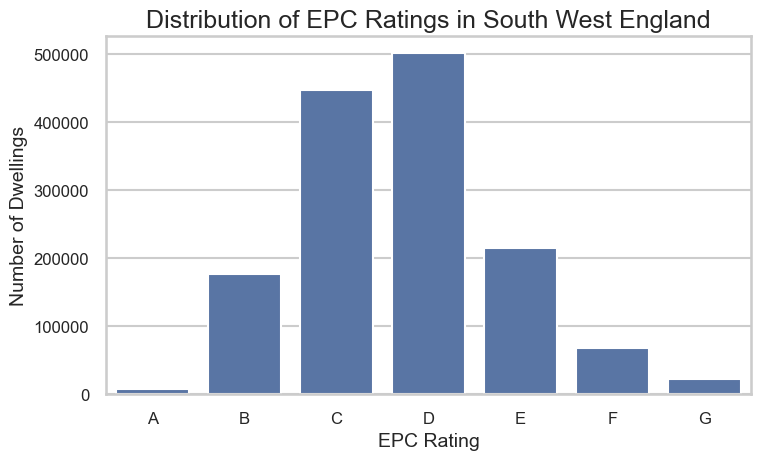

In [41]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_eda,
    x="CURRENT_ENERGY_RATING",
    order=sorted(df_eda["CURRENT_ENERGY_RATING"].unique())
)

plt.title("Distribution of EPC Ratings in South West England")
plt.xlabel("EPC Rating")
plt.ylabel("Number of Dwellings")
plt.tight_layout()
plt.show()

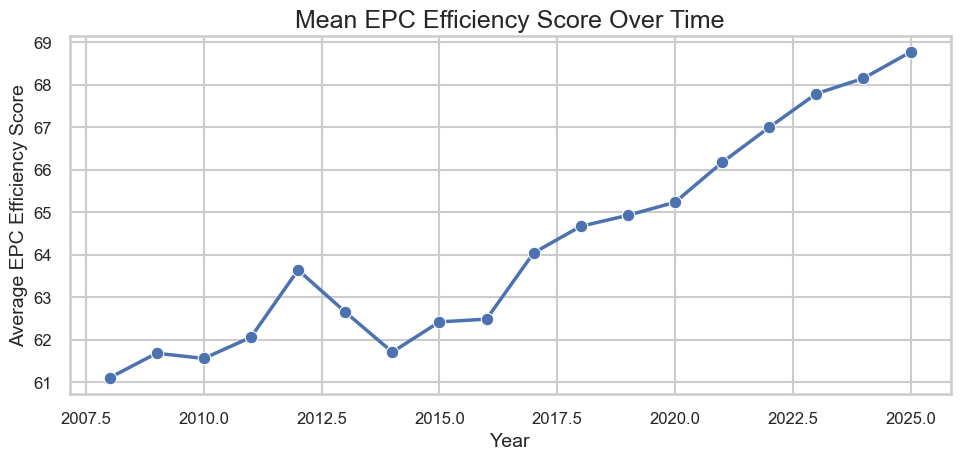

In [42]:

df_year = df_eda.groupby("YEAR")["CURRENT_ENERGY_EFFICIENCY"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(
    data=df_year,
    x="YEAR",
    y="CURRENT_ENERGY_EFFICIENCY",
    marker="o",
    linewidth=2.5
)

plt.title("Mean EPC Efficiency Score Over Time")
plt.xlabel("Year")
plt.ylabel("Average EPC Efficiency Score")
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_39656/1359880400.py:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/divyanshu/.pyenv/versions/3.11.9/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


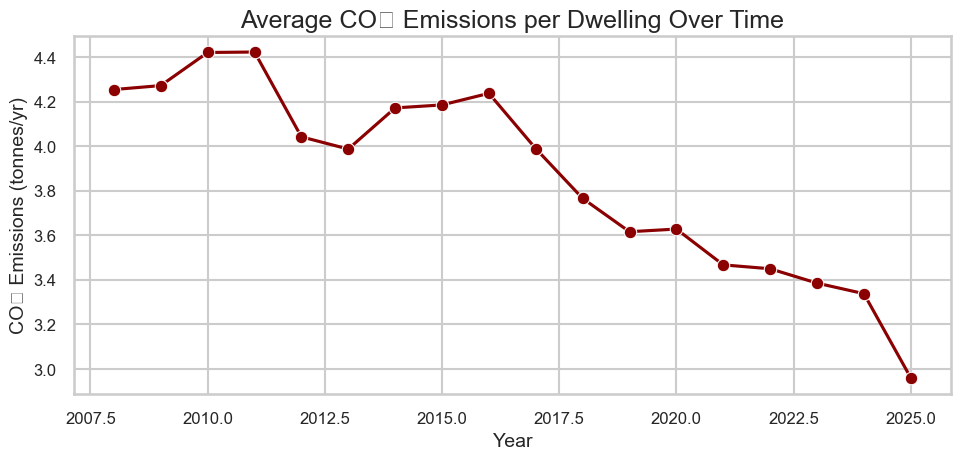

In [43]:
df_year = df_eda.groupby("YEAR")["CO2_EMISSIONS_CURRENT"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(
    data=df_year,
    x="YEAR",
    y="CO2_EMISSIONS_CURRENT",
    marker="o",
    color="darkred"
)

plt.title("Average CO₂ Emissions per Dwelling Over Time")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (tonnes/yr)")
plt.tight_layout()
plt.show()

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_39656/69682162.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


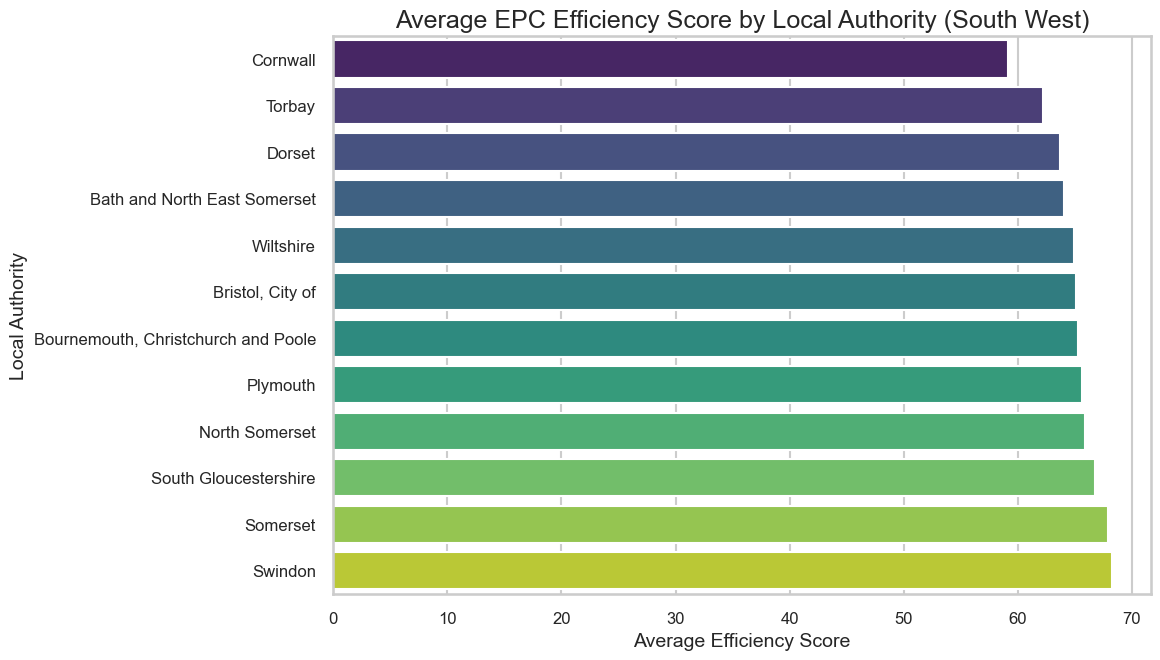

In [44]:
la_mean = (
    df_eda
    .groupby("LOCAL_AUTHORITY_LABEL")["CURRENT_ENERGY_EFFICIENCY"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(12,7))
sns.barplot(
    x=la_mean.values,
    y=la_mean.index,
    palette="viridis"
)

plt.title("Average EPC Efficiency Score by Local Authority (South West)")
plt.xlabel("Average Efficiency Score")
plt.ylabel("Local Authority")
plt.tight_layout()
plt.show()

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_39656/497678503.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


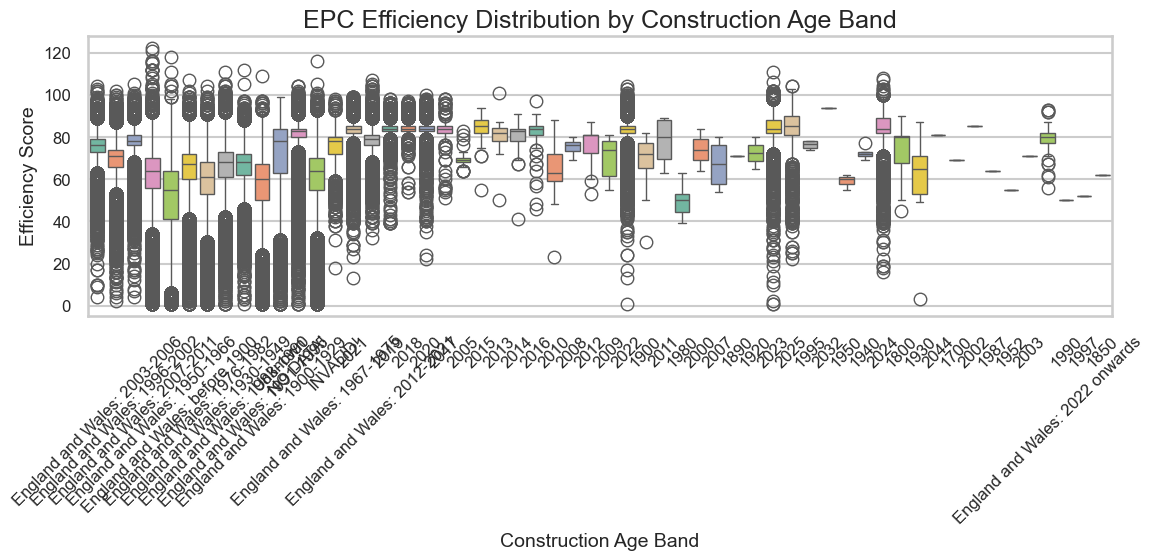

In [45]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_eda,
    x="AGE_BAND_STD",
    y="CURRENT_ENERGY_EFFICIENCY",
    palette="Set2"
)

plt.title("EPC Efficiency Distribution by Construction Age Band")
plt.xlabel("Construction Age Band")
plt.ylabel("Efficiency Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/gs/6gjhnpdn0zd0p99jkjwdr0700000gn/T/ipykernel_39656/217287785.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


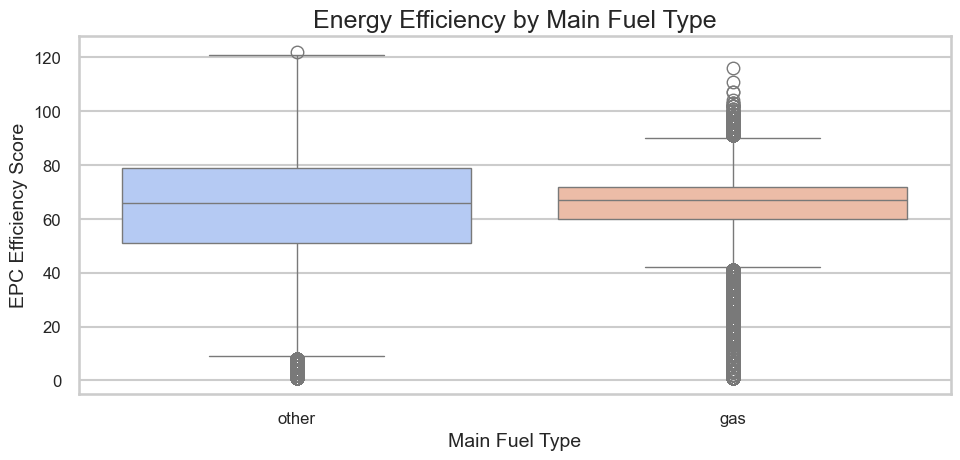

In [46]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_eda,
    x="MAIN_FUEL_STD",
    y="CURRENT_ENERGY_EFFICIENCY",
    palette="coolwarm"
)

plt.title("Energy Efficiency by Main Fuel Type")
plt.xlabel("Main Fuel Type")
plt.ylabel("EPC Efficiency Score")
plt.tight_layout()
plt.show()

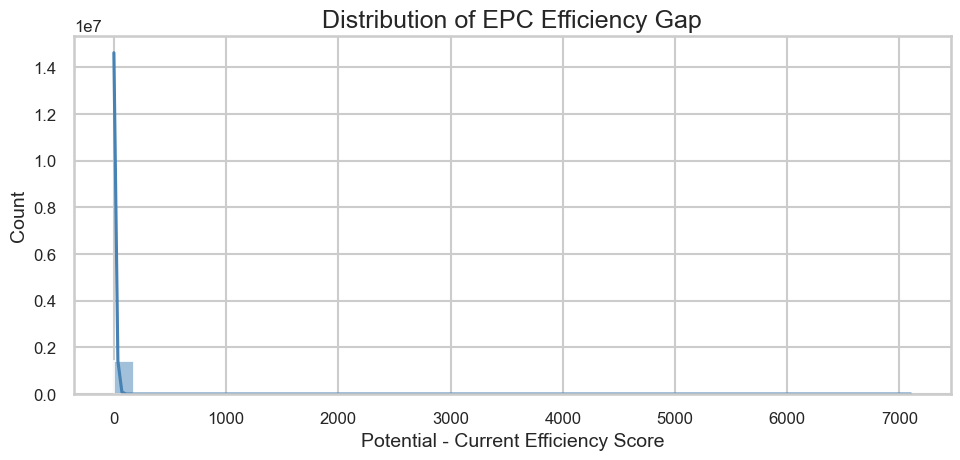

In [47]:
plt.figure(figsize=(10,5))
sns.histplot(
    df_eda["EFFICIENCY_GAP"],
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of EPC Efficiency Gap")
plt.xlabel("Potential - Current Efficiency Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

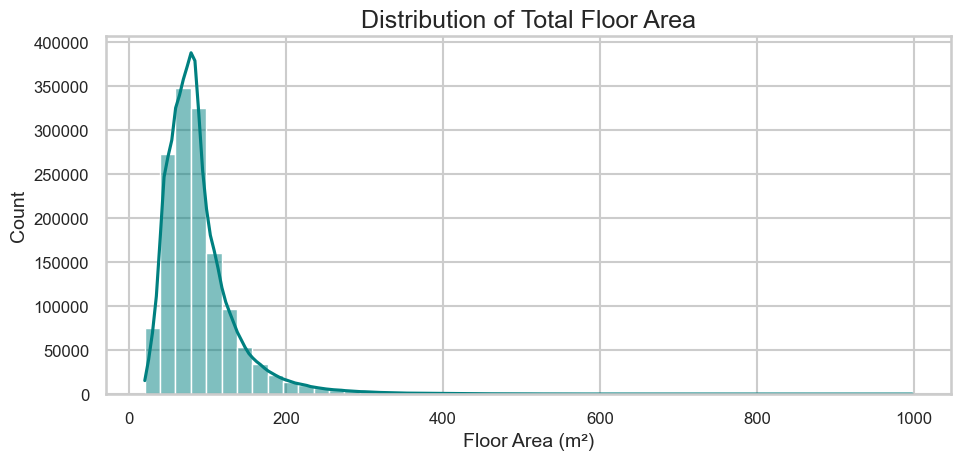

In [48]:
plt.figure(figsize=(10,5))
sns.histplot(
    df_eda["TOTAL_FLOOR_AREA"],
    bins=50,
    kde=True,
    color="teal"
)

plt.title("Distribution of Total Floor Area")
plt.xlabel("Floor Area (m²)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

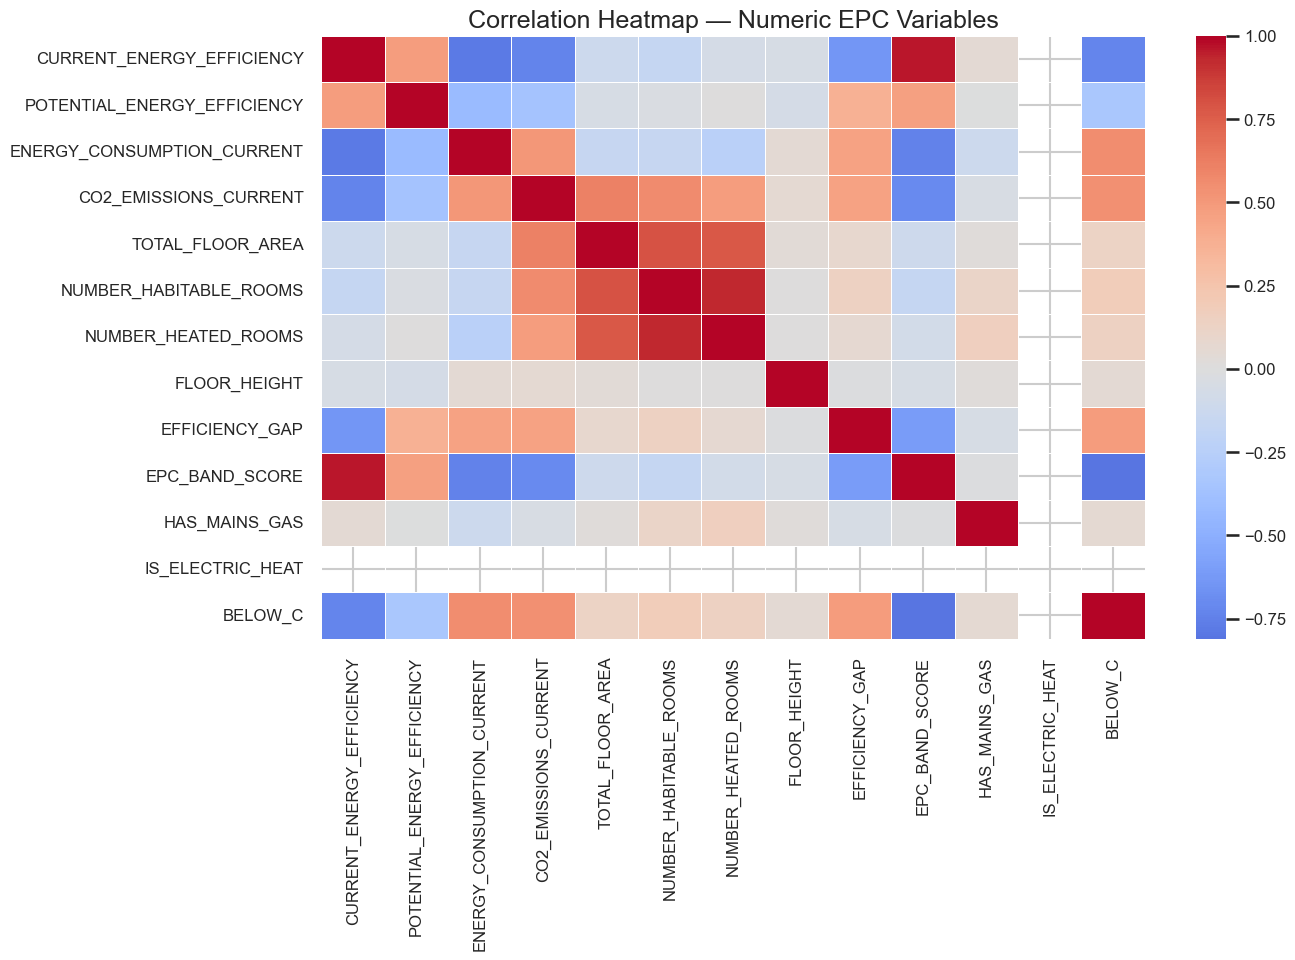

In [49]:
numeric_cols = df_eda.select_dtypes(include=["float64", "int64", "bool"]).columns
corr = df_eda[numeric_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=.5
)

plt.title("Correlation Heatmap — Numeric EPC Variables")
plt.tight_layout()
plt.show()

In [50]:
import pandas as pd

# assuming df already loaded
def assign_policy_period(year: int) -> str:
    if year <= 2012:
        return "Pre-2013 (pre-ECO/Green Deal)"
    elif 2013 <= year <= 2015:
        return "2013-2015 (Green Deal + ECO1)"
    elif 2016 <= year <= 2017:
        return "2016-2017 (ECO2, pre-MEES)"
    elif 2018 <= year <= 2019:
        return "2018-2019 (MEES intro)"
    else:
        return "2020+ (post-MEES & CED wave)"

df["POLICY_PERIOD"] = df["YEAR"].apply(assign_policy_period)

# Simple "post climate emergency wave" flag:
df["POST_CED_WAVE"] = df["YEAR"] >= 2020

AttributeError: 'Series' object has no attribute 'apply'

## Fuel Type X Year interactions, because this directly answers
- Does electrification increase after CED/LAEP?
- Are EPC scores rising specifically for "other" fuels (heat pumps)?
- Did MESS push gas-heated private rentals to upgrade?



In [51]:
fuel_year = df.groupby(["YEAR", "MAIN_FUEL_STD"])["LMK_KEY"].count().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=fuel_year, x="YEAR", y="LMK_KEY", hue="MAIN_FUEL_STD", marker="o")
plt.title("Fuel Type Composition Over Time — South West England")
plt.ylabel("Number of Dwellings")
plt.show()

AttributeError: 'DataFrame' object has no attribute 'groupby'

In [52]:
type(df)

polars.dataframe.frame.DataFrame